<a href="https://colab.research.google.com/github/wyogifirdaus-sudo/Sentiment-Kelompok-kiri/blob/main/sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from googleapiclient.discovery import build

**A function for crawling comments**

In [2]:
def video_comments(video_id, max_results=100): # Add maximum paramateres: max_results
    # empty list for storing reply
    replies = []

    # Creating a YouTube resource object
    youtube = build('youtube', 'v3', developerKey=api_key)
    # Build object YouTube resource with googleapclient.discovery.build,
    # With API version V3. api_key is a key of the API for opened data accsess from YouTube.

    # Retrieve Youtube video results
    video_response = youtube.commentThreads().list(
        part='snippet,replies',
        videoId=video_id,
        maxResults=min(max_results, 100)
        ).execute()
    # Pull main comments from video as video_id, with parameter part='snippet, replies'
    # Define data for resources. Data has basic information (snippet) and reply (replies).

    # Counter for comment count, just take it
    comment_count = 0

    # Iterate video response
    while video_response and comment_count < max_results:

        # extracting required info
        # from each result object
        for item in video_response['items']:

            # Extracting comments ()
            published = item['snippet']['topLevelComment']['snippet']['publishedAt'] # As a publish comment
            user = item['snippet']['topLevelComment']['snippet']['authorDisplayName'] #User name comment

            # Extracting comments ()
            comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
            likeCount = item['snippet']['topLevelComment']['snippet']['likeCount'] #Count like on comment

            replies.append([published, user, comment, likeCount])
            comment_count += 1 # Add counter

            # Counting the number of replies to comment
            replycount = item['snippet']['totalReplyCount']

            # If reply is there
            if replycount > 0:

                # Iterate through all replies
                for reply in item['replies']['comments']:

                    # Extract reply
                    published = reply['snippet']['publishedAt']
                    user = reply['snippet']['authorDisplayName']
                    comment = reply['snippet']['textDisplay']
                    likeCount = reply['snippet']['likeCount']

                    # Store reply is list
                    #replies.append(reply)
                    replies.append([published, user, comment, likeCount])
                    comment_count += 1 # Add counter
                    if comment_count >= max_results:
                        break #
            if comment_count >= max_results:
                break

        # Again repeat
        if 'nextPageToken' in video_response and comment_count < max_results:
            video_response = youtube.commentThreads().list(
                part='snippet,replies',
                videoId=video_id,
                pageToken=video_response['nextPageToken'],
                maxResults=min(max_results - comment_count, 100)
                ).execute()
        else:
            break
    #endwhile
    return replies


**Crawling Comments**

Monitoring commments on the film: Penumpasan Pengkhianatan G30S was published on *@Hendra Ahya*

https://youtu.be/nxO4819nMNc?si=ZEMiGi-rQWb5NjaM

In [3]:
!pip install langchain-google-genai
from langchain_google_genai import ChatGoogleGenerativeAI
from google.colab import userdata
from googleapiclient.discovery import build

import os
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
api_key = os.environ["GOOGLE_API_KEY"]

# Redefine video_comments here to ensure api_key is in scope.
def video_comments(video_id, max_results=100):
    replies = []
    youtube = build('youtube', 'v3', developerKey=api_key)

    video_response = youtube.commentThreads().list(
        part='snippet,replies',
        videoId=video_id,
        maxResults=min(max_results, 100)
        ).execute()

    comment_count = 0

    while video_response and comment_count < max_results:
        for item in video_response['items']:
            published = item['snippet']['topLevelComment']['snippet']['publishedAt']
            user = item['snippet']['topLevelComment']['snippet']['authorDisplayName']
            comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
            likeCount = item['snippet']['topLevelComment']['snippet']['likeCount']

            replies.append([published, user, comment, likeCount])
            comment_count += 1

            replycount = item['snippet']['totalReplyCount']

            if replycount > 0:
                for reply in item['replies']['comments']:
                    published = reply['snippet']['publishedAt']
                    user = reply['snippet']['authorDisplayName']
                    comment = reply['snippet']['textDisplay']
                    likeCount = reply['snippet']['likeCount']

                    replies.append([published, user, comment, likeCount])
                    comment_count += 1
                    if comment_count >= max_results:
                        break
            if comment_count >= max_results:
                break

        if 'nextPageToken' in video_response and comment_count < max_results:
            video_response = youtube.commentThreads().list(
                part='snippet,replies',
                videoId=video_id,
                pageToken=video_response['nextPageToken'],
                maxResults=min(max_results - comment_count, 100)
                ).execute()
        else:
            break
    return replies

gemini = ChatGoogleGenerativeAI(
    model="gemini-1.5-pro"
)

# Enter video id
video_id = "nxO4819nMNc"

# Count data for pulling it
jumlah_data = 12000

# Call fuction with data counted
comments = video_comments(video_id, jumlah_data)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 22.1 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.12.1
    Uninstalling google-genai-2.12.1:
      Successfully uninstalled google-genai-2.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.1 which is incompatible.


In [4]:
# Check if the data is saved
print(f"Jumlah data tersimpan sebanyak : {len(comments)}")

Jumlah data tersimpan sebanyak : 10091


In [5]:
df = pd.DataFrame(comments, columns=['published', 'user', 'comment', 'likeCount'])
df

,published,user,comment,likeCount
0,2026-09-24T13:36:50Z,@niswaniutami4089,Nonton 24 okt 2026,0
1,2026-09-24T11:55:53Z,@Arif-d4m2y,"Bulan september 2026, apakah masih ada yg nont...",0
2,2026-09-23T06:57:42Z,@JyToBiles,"<a href=""https://www.youtube.com/watch?v=nxO48...",0
3,2026-09-23T02:55:12Z,@MulyadiHamzah-ki3eg,Takdir Alloh mnyisakan banyak saksi &#39;terim...,0
4,2026-09-18T11:05:02Z,@Tanzy-Elitis,Gw bakal balik lagi tanggal 30,0
...,...,...,...,...
10086,2017-09-28T17:02:28Z,@dormanborisman77,ada kualitas restorasi seluloid film aslinya?,8
10087,2017-09-27T11:09:22Z,@yorushiku1234,Ini yg asli bukan?,4
10088,2018-08-23T17:26:53Z,@akbaralfatahahmad1852,Itu cerita SDH .di ubah ikut telunjuk orba . S...,0
10089,2018-09-08T20:32:28Z,@adrianahendy3009,Neh aspal orba.,0


In [6]:
df = df[~df['comment'].str.contains('http://|https://', na=False)] #Erased row of four caused this comment just input link YouTube for make sure metode shown a real sentiment

In [7]:
df.to_csv('youtube-g30s-22sep26.csv', index=False) #Saving crawling comments into CSV

In [8]:
import pandas as pd
data = pd.read_csv("/content/youtube-g30s-22sep26.csv", on_bad_lines='warn')
data.head()

,published,user,comment,likeCount
0,2026-09-24T13:36:50Z,@niswaniutami4089,Nonton 24 okt 2026,0
1,2026-09-24T11:55:53Z,@Arif-d4m2y,"Bulan september 2026, apakah masih ada yg nont...",0
2,2026-09-23T02:55:12Z,@MulyadiHamzah-ki3eg,Takdir Alloh mnyisakan banyak saksi &#39;terim...,0
3,2026-09-18T11:05:02Z,@Tanzy-Elitis,Gw bakal balik lagi tanggal 30,0
4,2026-09-17T17:15:34Z,@UlungSadewo22,Hp tk bakso.,0


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9379 entries, 0 to 9378
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   published  9379 non-null   object
 1   user       9379 non-null   object
 2   comment    9379 non-null   object
 3   likeCount  9379 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 293.2+ KB


In [10]:
data.describe()

,likeCount
count,9379.000000
mean,6.226037
std,87.481681
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,5384.000000


In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.drop_duplicates(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9379 entries, 0 to 9378
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   published  9379 non-null   object
 1   user       9379 non-null   object
 2   comment    9379 non-null   object
 3   likeCount  9379 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 293.2+ KB


In [13]:
data.isna().sum()

,0
published,0
user,0
comment,0
likeCount,0


In [14]:
data = pd.DataFrame(data[['user', 'comment']])
data.head()

,user,comment
0,@niswaniutami4089,Nonton 24 okt 2026
1,@Arif-d4m2y,"Bulan september 2026, apakah masih ada yg nont..."
2,@MulyadiHamzah-ki3eg,Takdir Alloh mnyisakan banyak saksi &#39;terim...
3,@Tanzy-Elitis,Gw bakal balik lagi tanggal 30
4,@UlungSadewo22,Hp tk bakso.


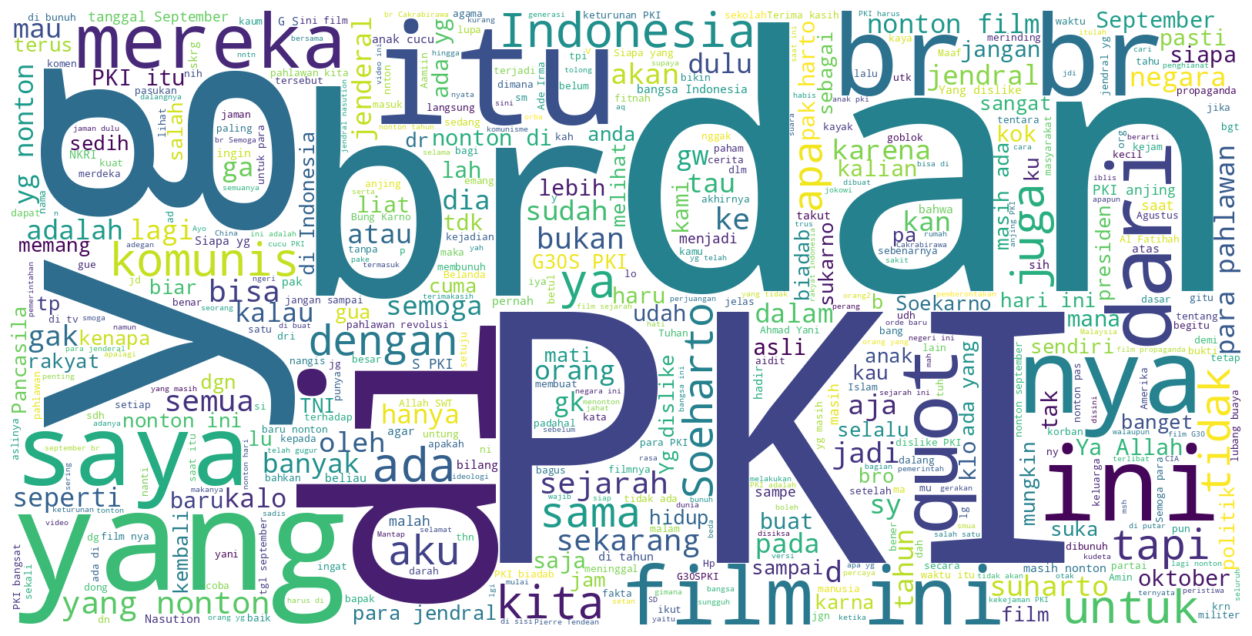

In [15]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

data['comment'] = data['comment'].fillna('')

text = ' '.join(data['comment'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp'])

wc = WordCloud(stopwords=stopwords, background_color='white', max_words=500, width=1600, height=800)
wc.generate(text)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

**Word Frequences before
Prepocessing**

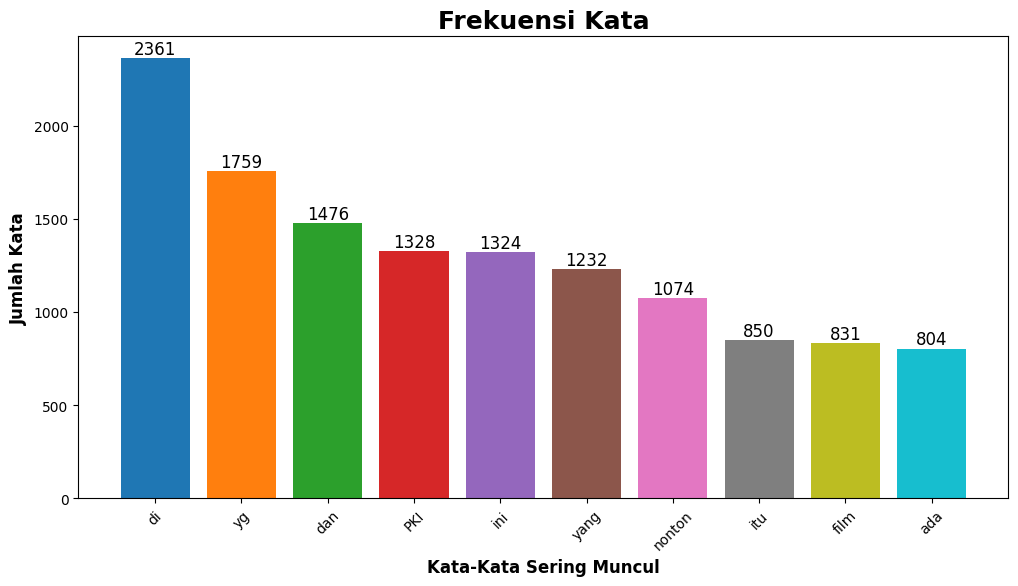

In [16]:
import matplotlib.pyplot as plt
from collections import Counter

text = " ".join(data['comment'])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel('Kata-Kata Sering Muncul', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Kata', fontsize=12, fontweight='bold')
plt.title('Frekuensi Kata', fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas tiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(num), ha='center', va='bottom', fontsize=12, color='black')
plt.show()

**Cleaning Processing**

In [17]:
import re
import string
import nltk

# Function for erase emoji
def remove_emoji(tweet):
  if tweet is not None and isinstance(tweet, str):
      emoji_pattern = re.compile("["
                                u"\U0001F600-\U0001F64F"  # emoticons
                                u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                                u"\U0001F680-\U0001F6FF"  # transport & map symbols
                                u"\U0001F700-\U0001F77F"  # alchemical symbols
                                u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
                                u"\U0001F800-\U0001F8FF"  # Supplemental Arrows -C
                                u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
                                u"\U0001FA00-\U0001FA6F"  # Chess Symbols
                                u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
                                u"\U0001F004-\U0001F0CF"  # Additional emoticons
                                u"\U0001F1E0-\U0001F1FF"  # flags
                                                    "]+", flags=re.UNICODE)
      return emoji_pattern.sub(r'', tweet)
  else:
      return tweet

# Function for erase symbols
def remove_symbols(tweet):
  if tweet is not None and isinstance(tweet, str):
      tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet) # Erase all Symbols
  return tweet

# Function for erase numbers
def remove_numbers(tweet):
  if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet) # Erase all numbers
  return tweet

# Function for erase username
def remove_username(tweet):
  import re
  return re.sub(r'@\w+', '', tweet) # Changed 'text' to 'tweet' as per function argument

# Function for erase URL
def remove_url(text):
  url_pattern = re.compile(r'https?://\S+|www\.\S+')
  return url_pattern.sub(r'', text)

#Function for erase html
def remove_html(text):
  html_pattern = re.compile('<.*?>')
  return html_pattern.sub(r'', text)

data['cleaning'] = data['comment'].apply(lambda x: remove_emoji(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_symbols(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_numbers(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_username(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_html(x))

data.head()

,user,comment,cleaning
0,@niswaniutami4089,Nonton 24 okt 2026,Nonton okt
1,@Arif-d4m2y,"Bulan september 2026, apakah masih ada yg nont...",Bulan september apakah masih ada yg nonton fi...
2,@MulyadiHamzah-ki3eg,Takdir Alloh mnyisakan banyak saksi &#39;terim...,Takdir Alloh mnyisakan banyak saksi terimakasi...
3,@Tanzy-Elitis,Gw bakal balik lagi tanggal 30,Gw bakal balik lagi tanggal
4,@UlungSadewo22,Hp tk bakso.,Hp tk bakso


**Case Folding Processing**

In [18]:
def case_folding(text):
  if isinstance(text, str):
    lowercase_text = text.lower()
    return lowercase_text
  else:
    return text

data['case_folding'] = data['cleaning'].apply(case_folding)
data.head()

,user,comment,cleaning,case_folding
0,@niswaniutami4089,Nonton 24 okt 2026,Nonton okt,nonton okt
1,@Arif-d4m2y,"Bulan september 2026, apakah masih ada yg nont...",Bulan september apakah masih ada yg nonton fi...,bulan september apakah masih ada yg nonton fi...
2,@MulyadiHamzah-ki3eg,Takdir Alloh mnyisakan banyak saksi &#39;terim...,Takdir Alloh mnyisakan banyak saksi terimakasi...,takdir alloh mnyisakan banyak saksi terimakasi...
3,@Tanzy-Elitis,Gw bakal balik lagi tanggal 30,Gw bakal balik lagi tanggal,gw bakal balik lagi tanggal
4,@UlungSadewo22,Hp tk bakso.,Hp tk bakso,hp tk bakso


**Words Normalize**

In [19]:
import pandas as pd

# Function for subtitute word doesn't on dictionaries
def replace_taboo_words(text, kamus_tidak_baku):
  if isinstance(text, str):
    words = text.split()
    replaced_words = []
    kalimat_baku = []
    kata_diganti = []
    kata_tidak_baku_hash = []

    for word in words:
      if word in kamus_tidak_baku:
        baku_word = kamus_tidak_baku[word]
        if isinstance(baku_word, str) and all (char.isalpha() or char.isspace() for char in baku_word):
          replaced_words.append(baku_word)
          kalimat_baku.append(baku_word)
          kata_diganti.append(word)
          kata_tidak_baku_hash.append(kamus_tidak_baku[word])
      else:
        replaced_words.append(word)
    replaced_text = ' '.join(replaced_words)
  else:
    replaced_text = ''
    kalimat_baku = []
    kata_diganti = []
    kata_tidak_baku_hash = []

  return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

In [20]:
# Reading Dataset
data.head()

,user,comment,cleaning,case_folding
0,@niswaniutami4089,Nonton 24 okt 2026,Nonton okt,nonton okt
1,@Arif-d4m2y,"Bulan september 2026, apakah masih ada yg nont...",Bulan september apakah masih ada yg nonton fi...,bulan september apakah masih ada yg nonton fi...
2,@MulyadiHamzah-ki3eg,Takdir Alloh mnyisakan banyak saksi &#39;terim...,Takdir Alloh mnyisakan banyak saksi terimakasi...,takdir alloh mnyisakan banyak saksi terimakasi...
3,@Tanzy-Elitis,Gw bakal balik lagi tanggal 30,Gw bakal balik lagi tanggal,gw bakal balik lagi tanggal
4,@UlungSadewo22,Hp tk bakso.,Hp tk bakso,hp tk bakso



**Download processing Slang dictionary on** https://www.kaggle.com/datasets/fornigulo/kamus-slag?resource=download

In [21]:
kamus_data = pd.read_excel('/content/kamuskatabaku.xlsx')
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))
kamus_data.head()

,tidak_baku,kata_baku
0,woww,wow
1,aminn,amin
2,met,selamat
3,netaas,menetas
4,keberpa,keberapa


In [22]:
data['hasil_normalisasi'], data['kalimat_baku'], data['kata_diganti'], data['kata_tidak_baku_hash'] = zip(*data['case_folding'].apply(lambda x: replace_taboo_words(x, kamus_tidak_baku)))
# data.head (100)
data  = pd.DataFrame(data[['user', 'comment', 'cleaning', 'case_folding', 'hasil_normalisasi']])
data.head()

,user,comment,cleaning,case_folding,hasil_normalisasi
0,@niswaniutami4089,Nonton 24 okt 2026,Nonton okt,nonton okt,menonton okt
1,@Arif-d4m2y,"Bulan september 2026, apakah masih ada yg nont...",Bulan september apakah masih ada yg nonton fi...,bulan september apakah masih ada yg nonton fi...,bulan september apakah masih ada yang menonton...
2,@MulyadiHamzah-ki3eg,Takdir Alloh mnyisakan banyak saksi &#39;terim...,Takdir Alloh mnyisakan banyak saksi terimakasi...,takdir alloh mnyisakan banyak saksi terimakasi...,takdir allah mnyisakan banyak saksi terimakasi...
3,@Tanzy-Elitis,Gw bakal balik lagi tanggal 30,Gw bakal balik lagi tanggal,gw bakal balik lagi tanggal,gue bakal balik lagi tanggal
4,@UlungSadewo22,Hp tk bakso.,Hp tk bakso,hp tk bakso,hp tak bakso


In [23]:
def tokenize(text):
    token = text.split()
    return token

data['tokenize'] = data['hasil_normalisasi'].apply(tokenize)
data.head()

,user,comment,cleaning,case_folding,hasil_normalisasi,tokenize
0,@niswaniutami4089,Nonton 24 okt 2026,Nonton okt,nonton okt,menonton okt,"[menonton, okt]"
1,@Arif-d4m2y,"Bulan september 2026, apakah masih ada yg nont...",Bulan september apakah masih ada yg nonton fi...,bulan september apakah masih ada yg nonton fi...,bulan september apakah masih ada yang menonton...,"[bulan, september, apakah, masih, ada, yang, m..."
2,@MulyadiHamzah-ki3eg,Takdir Alloh mnyisakan banyak saksi &#39;terim...,Takdir Alloh mnyisakan banyak saksi terimakasi...,takdir alloh mnyisakan banyak saksi terimakasi...,takdir allah mnyisakan banyak saksi terimakasi...,"[takdir, allah, mnyisakan, banyak, saksi, teri..."
3,@Tanzy-Elitis,Gw bakal balik lagi tanggal 30,Gw bakal balik lagi tanggal,gw bakal balik lagi tanggal,gue bakal balik lagi tanggal,"[gue, bakal, balik, lagi, tanggal]"
4,@UlungSadewo22,Hp tk bakso.,Hp tk bakso,hp tk bakso,hp tak bakso,"[hp, tak, bakso]"


In [24]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [25]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

data['stopword removal'] = data ['tokenize'].apply(lambda x: remove_stopwords(x))
data.head()

,user,comment,cleaning,case_folding,hasil_normalisasi,tokenize,stopword removal
0,@niswaniutami4089,Nonton 24 okt 2026,Nonton okt,nonton okt,menonton okt,"[menonton, okt]","[menonton, okt]"
1,@Arif-d4m2y,"Bulan september 2026, apakah masih ada yg nont...",Bulan september apakah masih ada yg nonton fi...,bulan september apakah masih ada yg nonton fi...,bulan september apakah masih ada yang menonton...,"[bulan, september, apakah, masih, ada, yang, m...","[september, menonton, film]"
2,@MulyadiHamzah-ki3eg,Takdir Alloh mnyisakan banyak saksi &#39;terim...,Takdir Alloh mnyisakan banyak saksi terimakasi...,takdir alloh mnyisakan banyak saksi terimakasi...,takdir allah mnyisakan banyak saksi terimakasi...,"[takdir, allah, mnyisakan, banyak, saksi, teri...","[takdir, allah, mnyisakan, saksi, terimakasih,..."
3,@Tanzy-Elitis,Gw bakal balik lagi tanggal 30,Gw bakal balik lagi tanggal,gw bakal balik lagi tanggal,gue bakal balik lagi tanggal,"[gue, bakal, balik, lagi, tanggal]","[gue, tanggal]"
4,@UlungSadewo22,Hp tk bakso.,Hp tk bakso,hp tk bakso,hp tak bakso,"[hp, tak, bakso]","[hp, bakso]"


**Stemming Data Processing**

In [26]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.3 MB/s eta 0:00:00


In [27]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return [stemmer.stem(word) for word in text]

data['stemming'] = data['stopword removal'].apply(lambda x: ' '.join(stem_text(x)))
data.head()

,user,comment,cleaning,case_folding,hasil_normalisasi,tokenize,stopword removal,stemming
0,@niswaniutami4089,Nonton 24 okt 2026,Nonton okt,nonton okt,menonton okt,"[menonton, okt]","[menonton, okt]",tonton okt
1,@Arif-d4m2y,"Bulan september 2026, apakah masih ada yg nont...",Bulan september apakah masih ada yg nonton fi...,bulan september apakah masih ada yg nonton fi...,bulan september apakah masih ada yang menonton...,"[bulan, september, apakah, masih, ada, yang, m...","[september, menonton, film]",september tonton film
2,@MulyadiHamzah-ki3eg,Takdir Alloh mnyisakan banyak saksi &#39;terim...,Takdir Alloh mnyisakan banyak saksi terimakasi...,takdir alloh mnyisakan banyak saksi terimakasi...,takdir allah mnyisakan banyak saksi terimakasi...,"[takdir, allah, mnyisakan, banyak, saksi, teri...","[takdir, allah, mnyisakan, saksi, terimakasih,...",takdir allah mnyisakan saksi terimakasih ya al...
3,@Tanzy-Elitis,Gw bakal balik lagi tanggal 30,Gw bakal balik lagi tanggal,gw bakal balik lagi tanggal,gue bakal balik lagi tanggal,"[gue, bakal, balik, lagi, tanggal]","[gue, tanggal]",gue tanggal
4,@UlungSadewo22,Hp tk bakso.,Hp tk bakso,hp tk bakso,hp tak bakso,"[hp, tak, bakso]","[hp, bakso]",hp bakso


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9379 entries, 0 to 9378
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user               9379 non-null   object
 1   comment            9379 non-null   object
 2   cleaning           9379 non-null   object
 3   case_folding       9379 non-null   object
 4   hasil_normalisasi  9379 non-null   object
 5   tokenize           9379 non-null   object
 6   stopword removal   9379 non-null   object
 7   stemming           9379 non-null   object
dtypes: object(8)
memory usage: 586.3+ KB


In [29]:
data.describe()

,user,comment,cleaning,case_folding,hasil_normalisasi,tokenize,stopword removal,stemming
count,9379,9379,9379,9379,9379,9379,9379,9379
unique,7207,8913,8543,8412,8195,8195,7745,7715
top,@sintamarlena6370,Hadir,,,,[],[],
freq,190,18,254,254,264,264,434,434


In [30]:
data.isna().sum()

,0
user,0
comment,0
cleaning,0
case_folding,0
hasil_normalisasi,0
tokenize,0
stopword removal,0
stemming,0


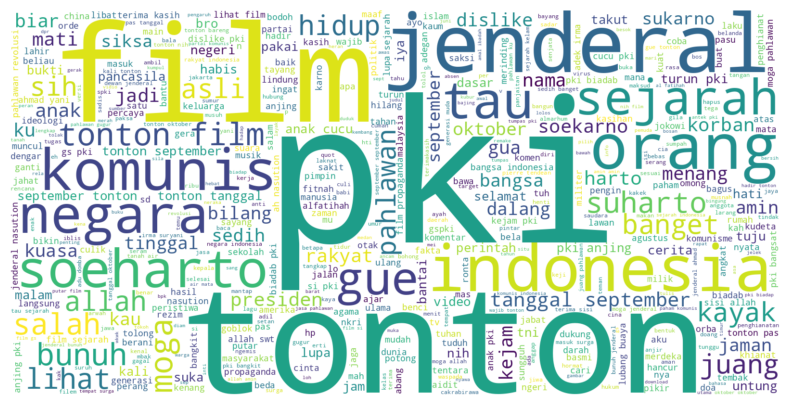

In [31]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Unity text from coloumn 'streaming'
text = ' '.join(data['stemming'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https','co', 'youtube', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya'])

wc = WordCloud(stopwords=stopwords, background_color='white', max_words=500, width=1600, height=800)
wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

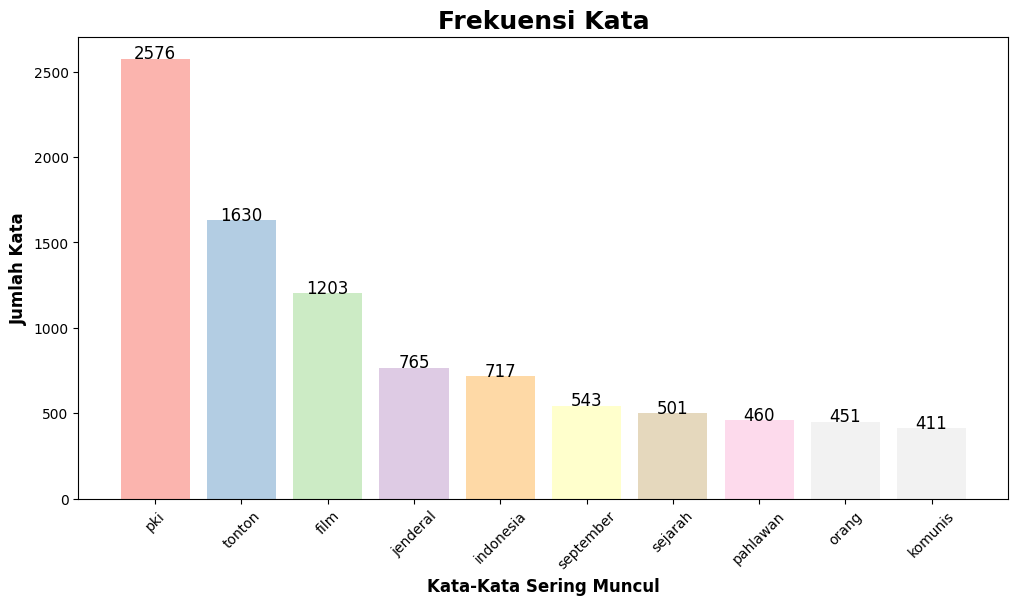

In [32]:
import matplotlib.pyplot as plt
from wordcloud import STOPWORDS
from collections import Counter

text = " ".join(data['stemming'])

stopwords = set(STOPWORDS)
stopwords.update(['https', 'youtube', 'comwa', 'href', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'br', 'yg', 'ya'])

tokens = [word for word in text.split() if word not in stopwords]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)

# Use color more soft
colors = plt.cm.Pastel1(range(len(word)))

# Build the plot
plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel('Kata-Kata Sering Muncul', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Kata', fontsize=12, fontweight='bold')
plt.title ('Frekuensi Kata', fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas tiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 1.6 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Showing the plot
plt.show

In [33]:
# Saving to CSV
data.to_csv('data_preprocessing.csv', index=False)

**Labelling Data**

In [34]:
import pandas as pd
data = pd.read_csv('/content/data_preprocessing.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9379 entries, 0 to 9378
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user               9379 non-null   object
 1   comment            9379 non-null   object
 2   cleaning           9125 non-null   object
 3   case_folding       9125 non-null   object
 4   hasil_normalisasi  9115 non-null   object
 5   tokenize           9379 non-null   object
 6   stopword removal   9379 non-null   object
 7   stemming           8945 non-null   object
dtypes: object(8)
memory usage: 586.3+ KB


In [35]:
data = pd.DataFrame(data[['stemming']])
data.head()

,stemming
0,tonton okt
1,september tonton film
2,takdir allah mnyisakan saksi terimakasih ya al...
3,gue tanggal
4,hp bakso


In [36]:
import pandas as pd
import requests
# Download positive and negative lexion of dictionary from Github
positive_url = 'https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv'
negative_url = 'https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv'

# Fetch content from URLs and create DataFrames
positive_response = requests.get(positive_url)
positive_lexion = set(pd.read_csv(pd.io.common.StringIO(positive_response.text), sep="\t", header=None)[0])

negative_response = requests.get(negative_url)
negative_lexion = set(pd.read_csv(pd.io.common.StringIO(negative_response.text), sep="\t", header=None)[0])

# Function for count positive and negative sentiments
def determine_sentiment(text):
  if isinstance(text, str):
    positive_count = sum(1 for word in text.split() if word in positive_lexion)
    negative_count = sum(1 for word in text.split() if word in negative_lexion)
    sentiment_score = positive_count - negative_count
    if sentiment_score > 0:
      sentiment = 'positive'
    elif sentiment_score < 0:
      sentiment = 'negative'
    else:
      sentiment = 'neutral'
    return sentiment_score, sentiment
  return 0, 'neutral'

# Subtituted sentimnet and score for every review
data[['score', 'label']] = data['stemming'].apply(lambda x: pd.Series(determine_sentiment(x)))
data.head()

,stemming,score,label
0,tonton okt,-1,negative
1,september tonton film,-1,negative
2,takdir allah mnyisakan saksi terimakasih ya al...,5,positive
3,gue tanggal,-1,negative
4,hp bakso,0,neutral


/tmp/ipykernel_1055/3389325295.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


<function matplotlib.pyplot.show(close=None, block=None)>

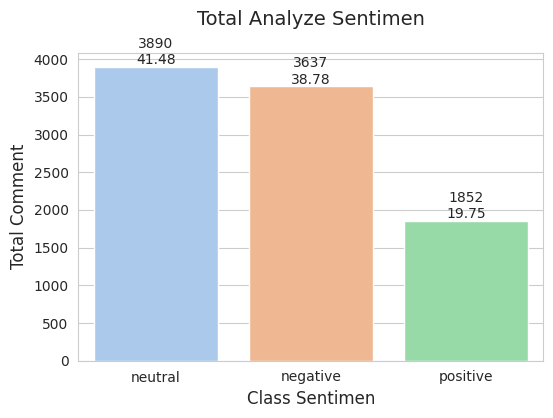

In [37]:
from matplotlib import axes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = data['label'].value_counts()
sns.set_style('whitegrid')

color_palette = {
    'positive': 'blue', # atau '#1f77b4' untuk warna biru yang lebih soft
    'neutral': 'green',  # atau '#2ca02c'
    'negative': 'red'    # atau '#d62728'
}

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Total Analyze Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentimen', fontsize=12)
plt.ylabel('Total Comment', fontsize=12)

total = len(data['label'])

for i, count in enumerate(sentiment_count.values):
  percentage = f'{100 * count / total:.2f}'
  ax.text(i, count + 0.10, f'{count}\n{percentage}', ha='center', va='bottom', fontsize=10)

plt.show

In [38]:
# Saving to csv
data.to_csv('data_labelling.csv', index=False)

**Wordcloud Label**

In [39]:
import pandas as pd

data = pd.read_csv('/content/data_labelling.csv')
data.head()

,stemming,score,label
0,tonton okt,-1,negative
1,september tonton film,-1,negative
2,takdir allah mnyisakan saksi terimakasih ya al...,5,positive
3,gue tanggal,-1,negative
4,hp bakso,0,neutral


In [40]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

#List words exception
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'yg', 'br'])

# Function for adding word cloud
def generate_wordcloud(text, tittle):
  wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(tittle, fontsize=14, pad=20)
  plt.show()

# Subtituted dataset as sentiment
sentiment_neutral = data[data['label'] == 'neutral']['stemming'].str.cat(sep=' ')
sentiment_positive = data[data['label'] == 'positive']['stemming'].str.cat(sep=' ')
sentiment_negative = data[data['label'] == 'negative']['stemming'].str.cat(sep=' ')

**Word Cloud as Labelling**

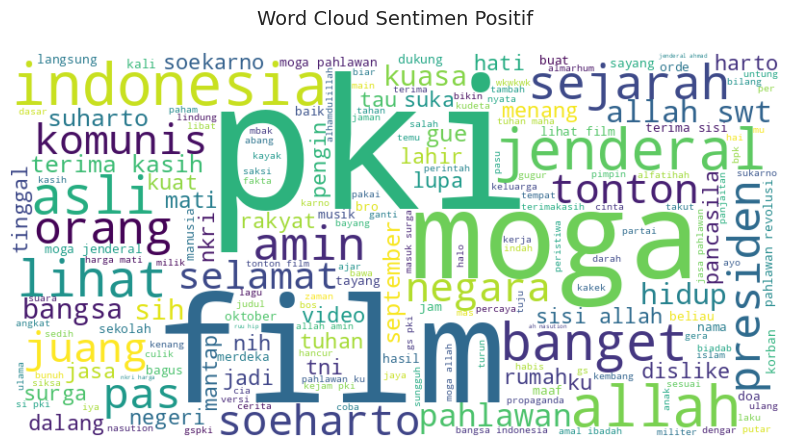

In [41]:
# Built word cloud for every sentiment
if sentiment_positive:
    generate_wordcloud(sentiment_positive, 'Word Cloud Sentimen Positif')
else:
    print("No positive comments found to generate a word cloud.")

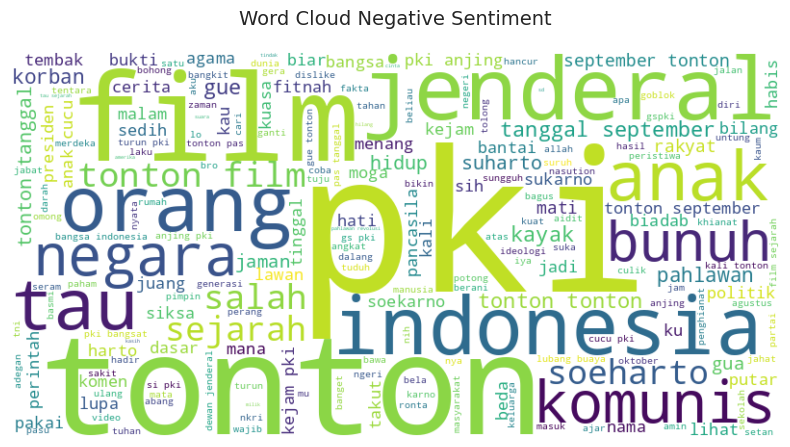

In [42]:
# Built word cloud for every sentiment
if sentiment_negative:
    generate_wordcloud(sentiment_negative, 'Word Cloud Negative Sentiment')
else:
    print("No negative comments found to generate a word cloud.")

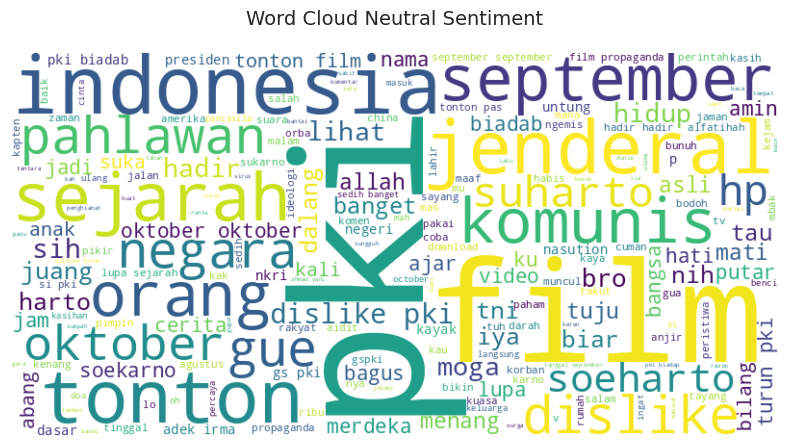

In [43]:
# Built word cloud for every sentiment
if sentiment_neutral:
    generate_wordcloud(sentiment_neutral, 'Word Cloud Neutral Sentiment')
else:
    print("No neutral comments found to generate a word cloud.")

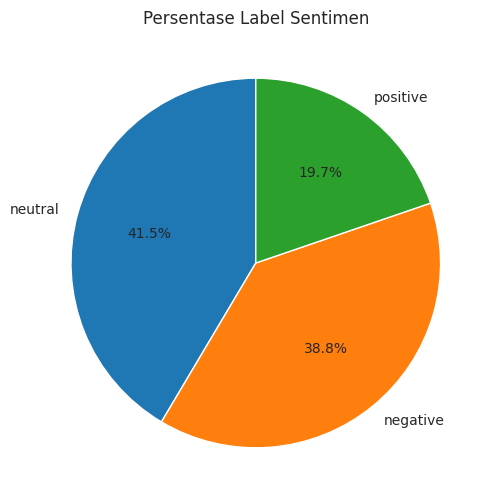

In [44]:
plt.figure(figsize=(6,6))

color_palette = {
    'positive': 'blue', # atau '#1f77b4' untuk warna biru yang lebih soft
    'neutral': 'green',  # atau '#2ca02c'
    'negative': 'red'    # atau '#800000'
}

plt.pie(
    sentiment_count,
    labels=sentiment_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Persentase Label Sentimen")
plt.show()

**Modelling Inport & Library**

In [45]:
data = pd.read_csv('/content/data_labelling.csv')
data.head()

,stemming,score,label
0,tonton okt,-1,negative
1,september tonton film,-1,negative
2,takdir allah mnyisakan saksi terimakasih ya al...,5,positive
3,gue tanggal,-1,negative
4,hp bakso,0,neutral


In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9379 entries, 0 to 9378
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   stemming  8945 non-null   object
 1   score     9379 non-null   int64 
 2   label     9379 non-null   object
dtypes: int64(1), object(2)
memory usage: 219.9+ KB


In [47]:
data_list = data['stemming'].tolist()
print(data_list)

['tonton okt', 'september tonton film', 'takdir allah mnyisakan saksi terimakasih ya allah negeri cinta mnyembahmu negeri komunis', 'gue tanggal', 'hp bakso', 'hp somay', 'pki sadis', 'al fatihah jenderal', 'yanto ya', 'absen tanggal september tonton', 'absenn', 'ya allah sesak menang kejer lihat adek ima suryani kena tembak berisik menang ya allah sang bingung hacur ankknya film nyata ya allah', 'tonton september angkat tangan', 'tonton angkat tangan', 'dalang america', 'tidur', 'sumpah sedih film dasar tindak genosida komunis masyarakat indonesiabr ratus ribu juta juta umat indonesia mati persekusi film gera soehartobrhingga kalang muda indonesia gspki justifikasi kuat bunuh banding tindak terorisme ekstrimis ideologi komunis ditangappi ratus genosida brtentu ide ide komunis marxist tolak pancasila ratus ribu orang indonesia depannyabrpls pemuda pancasila dont target me', 'ekonomi merosot', 'september', 'ulang film biar enak tonton', 'september absen', 'tonton september malaysia', 'm

**Feature Extraction TF-IDF**

Jumlah Data : 9379
Jumlah Label: 9379
Jumlah Data Training : 7503
Jumlah Data Testing  : 1876


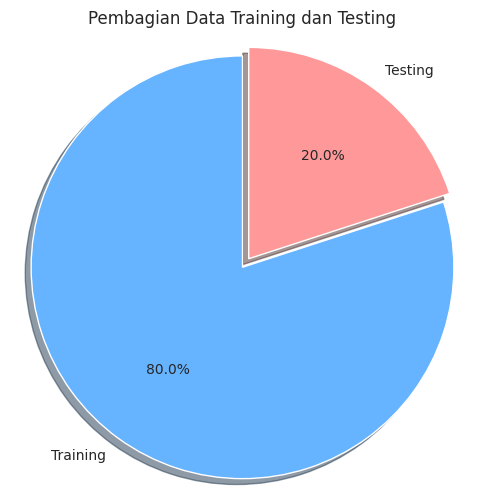

Shape Training : (7503, 5000)
Shape Testing  : (1876, 5000)
Jumlah Vocabulary : 5000
['aa' 'aaaaaaa' 'aaaamiiiiinn' 'aaaamiiiinnnn'
 'aaaannnjiiiinnggbangsatbandit' 'aaah' 'aaahhhhga' 'aahgk' 'aakuuuuuu'
 'aallah' 'aamiiiin' 'aamiinbrdan' 'aamiinn' 'aamiinx' 'aaminn'
 'aaminwaktu' 'aammiin' 'aan' 'aank' 'abad']


In [48]:
# ============================================================
# 1. Import Library
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# ============================================================
# 2. Menentukan Fitur (X) dan Label (y)
# ============================================================

# Kolom hasil preprocessing (ganti jika nama kolom berbeda)
X = data["stemming"]

# Fill NaN values with empty strings to prevent errors with TfidfVectorizer
X = X.fillna('')

# Kolom label
y = data["label"]

print("Jumlah Data :", len(X))
print("Jumlah Label:", len(y))

# ============================================================
# 3. Membagi Data Train dan Test
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y        # menjaga proporsi kelas
)

print("="*40)
print("Jumlah Data Training :", len(X_train))
print("Jumlah Data Testing  :", len(X_test))
print("="*40)

# ============================================================
# 4. Visualisasi Pembagian Data
# ============================================================

train_size = len(X_train)
test_size = len(X_test)

labels = ['Training', 'Testing']
sizes = [train_size, test_size]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0)

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    colors=colors,
    shadow=True
)
plt.title("Pembagian Data Training dan Testing")
plt.axis("equal")
plt.show()

# ============================================================
# 5. TF-IDF
# ============================================================

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,1)
)

# Fit hanya data training
X_train_tfidf = vectorizer.fit_transform(X_train)

# Data testing hanya transform
X_test_tfidf = vectorizer.transform(X_test)

print("="*40)
print("Shape Training :", X_train_tfidf.shape)
print("Shape Testing  :", X_test_tfidf.shape)
print("="*40)

# ============================================================
# 6. Menampilkan Vocabulary
# ============================================================

feature_names = vectorizer.get_feature_names_out()

print("Jumlah Vocabulary :", len(feature_names))
print(feature_names[:20])

**Machine Learning Classification Model**

--- Optimasi Logistic Regression ---
Best Parameters (LR) : {'C': 100, 'max_iter': 200, 'solver': 'lbfgs'}
Best CV Score (LR)   : 0.840691452867212

[Hasil Evaluasi Logistic Regression Setelah Tuning]
Accuracy: 0.8757995735607675
              precision    recall  f1-score   support

    negative       0.92      0.89      0.90       728
     neutral       0.85      0.88      0.87       778
    positive       0.85      0.84      0.84       370

    accuracy                           0.88      1876
   macro avg       0.87      0.87      0.87      1876
weighted avg       0.88      0.88      0.88      1876

Confusion Matrix:
 [[647  69  12]
 [ 47 687  44]
 [  8  53 309]]


Best Parameters (RF) : {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Score (RF)   : 0.8040854418902856

[Hasil Evaluasi Random Forest Setelah Tuning]
Accuracy: 0.8160980810234542
              precision    recall  f1-score   support

    negative       0.84      0.84   

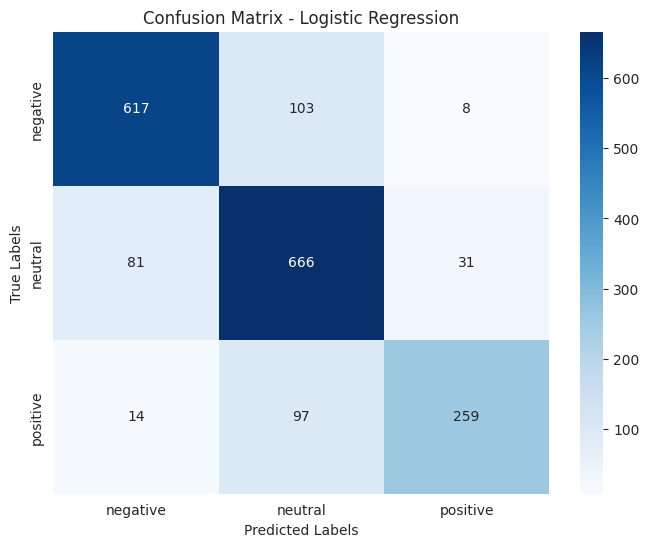

Classifer: Support Vector Machine
Accuracy: 0.8395522388059702
Classification Report:
               precision    recall  f1-score   support

    negative       0.87      0.86      0.87       728
     neutral       0.80      0.87      0.83       778
    positive       0.88      0.74      0.80       370

    accuracy                           0.84      1876
   macro avg       0.85      0.82      0.83      1876
weighted avg       0.84      0.84      0.84      1876

Confusion Matrix:
 [[628  92   8]
 [ 75 673  30]
 [ 19  77 274]]


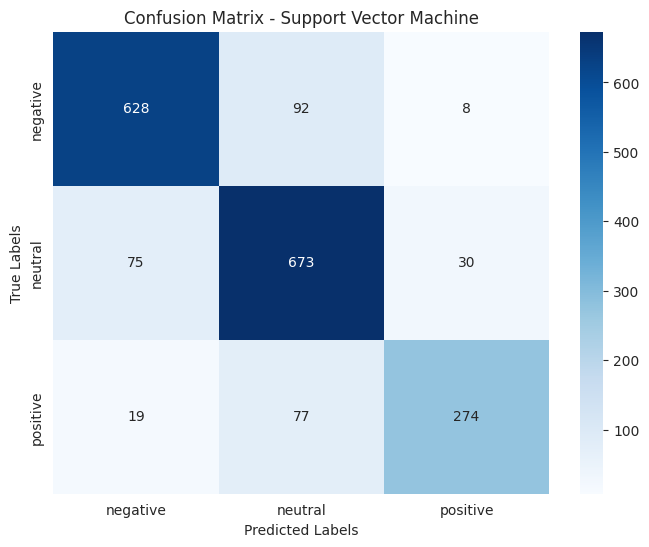

Classifer: Random Forest
Accuracy: 0.8267590618336887
Classification Report:
               precision    recall  f1-score   support

    negative       0.85      0.86      0.85       728
     neutral       0.83      0.82      0.83       778
    positive       0.79      0.77      0.78       370

    accuracy                           0.83      1876
   macro avg       0.82      0.82      0.82      1876
weighted avg       0.83      0.83      0.83      1876

Confusion Matrix:
 [[625  81  22]
 [ 81 641  56]
 [ 33  52 285]]


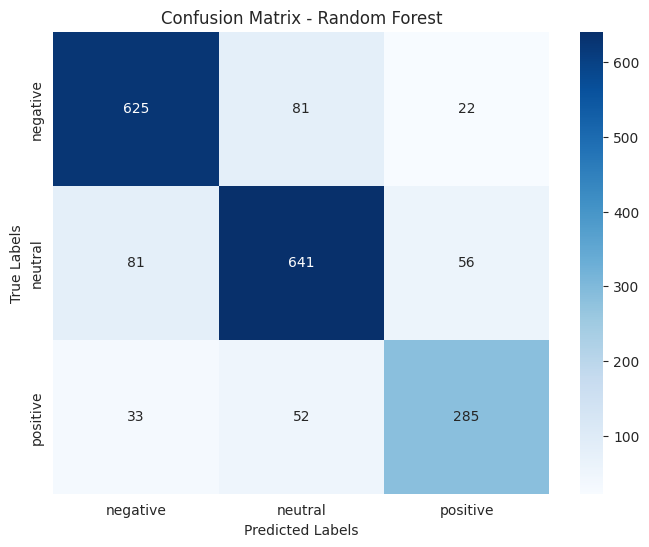

Classifer: Naive Bayes
Accuracy: 0.7249466950959488
Classification Report:
               precision    recall  f1-score   support

    negative       0.70      0.89      0.78       728
     neutral       0.71      0.72      0.71       778
    positive       0.92      0.42      0.57       370

    accuracy                           0.72      1876
   macro avg       0.78      0.67      0.69      1876
weighted avg       0.75      0.72      0.71      1876

Confusion Matrix:
 [[649  78   1]
 [209 557  12]
 [ 68 148 154]]


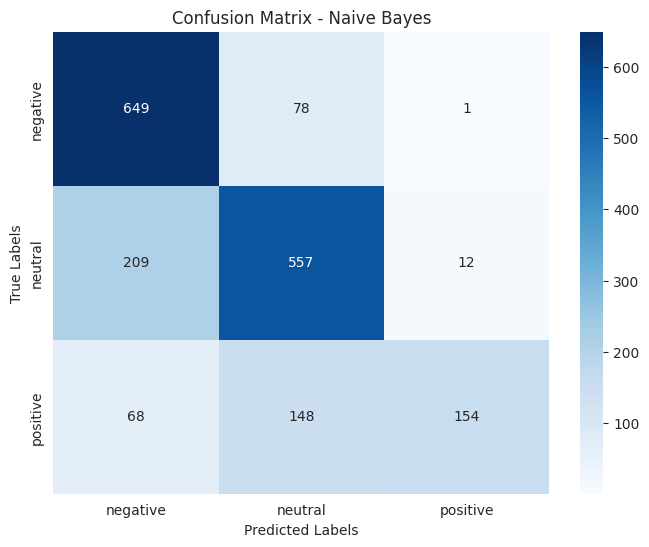

Classifer: K-Nearest Neighbors
Accuracy: 0.5767590618336887
Classification Report:
               precision    recall  f1-score   support

    negative       0.82      0.39      0.52       728
     neutral       0.50      0.91      0.64       778
    positive       0.83      0.25      0.39       370

    accuracy                           0.58      1876
   macro avg       0.72      0.52      0.52      1876
weighted avg       0.69      0.58      0.55      1876

Confusion Matrix:
 [[281 446   1]
 [ 53 707  18]
 [ 10 266  94]]


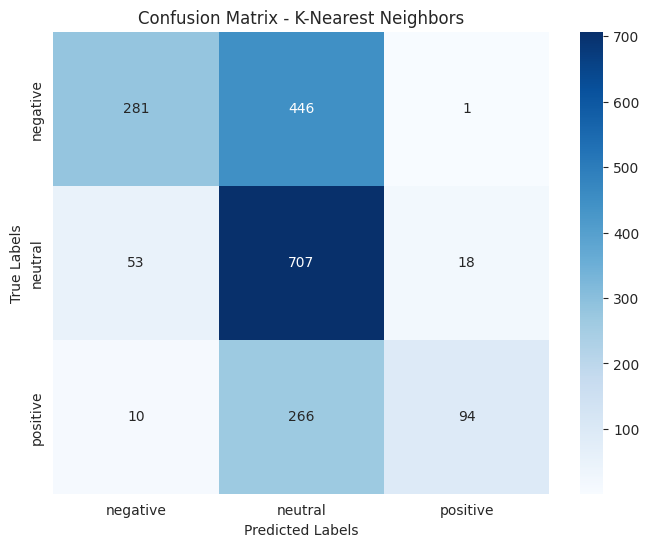

Classifer: Decision Tree
Accuracy: 0.7718550106609808
Classification Report:
               precision    recall  f1-score   support

    negative       0.81      0.79      0.80       728
     neutral       0.78      0.78      0.78       778
    positive       0.69      0.73      0.71       370

    accuracy                           0.77      1876
   macro avg       0.76      0.76      0.76      1876
weighted avg       0.77      0.77      0.77      1876

Confusion Matrix:
 [[575 108  45]
 [ 99 604  75]
 [ 35  66 269]]


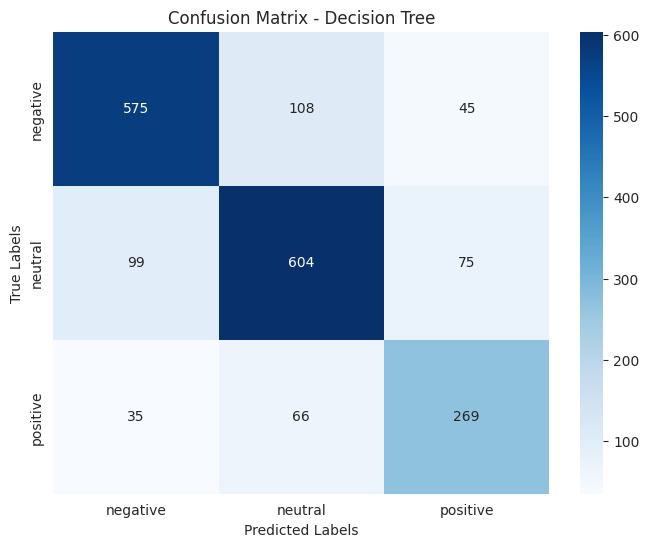

In [49]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Define dictionary of classiffers
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Support Vector Machine': SVC(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': MultinomialNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

# 1. GRID SEARCH: LOGISTIC REGRESSION
# ==========================================
print("--- Optimasi Logistic Regression ---")

# Tentukan parameter grid yang akan diuji
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],            # Mengontrol kekuatan regularisasi (makin besar = makin kompleks)
    'solver': ['lbfgs', 'liblinear', 'saga'],# Algoritma optimasi
    'max_iter': [200, 500]                   # Memastikan iterasi konvergen
}

# Inisialisasi GridSearchCV dengan 5-Fold Cross Validation
grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1_macro', # Bisa diganti 'f1_weighted' atau 'accuracy' sesuai kebutuhan
    n_jobs=-1
)

# Fit ke data latih (X_train & y_train)
grid_lr.fit(X_train_tfidf, y_train)

print("Best Parameters (LR) :", grid_lr.best_params_)
print("Best CV Score (LR)   :", grid_lr.best_score_)

# Evaluasi ke data uji (X_test)
best_lr_model = grid_lr.best_estimator_
y_pred_lr = best_lr_model.predict(X_test_tfidf)

print("\n[Hasil Evaluasi Logistic Regression Setelah Tuning]")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


print("\n" + "="*50 + "\n")

param_grid_rf = {
    'n_estimators': [50, 100, 200],      # Jumlah pohon keputusan
    'max_depth': [None, 10, 20, 30],      # Kedalaman maksimum pohon (membantu cegah overfitting)
    'min_samples_split': [2, 5, 10],      # Jumlah sampel minimum untuk membelah node
    'criterion': ['gini', 'entropy']     # Fungsi pengukur kualitas pembelahan
}

# Inisialisasi GridSearchCV
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Fit ke data latih (X_train & y_train)
grid_rf.fit(X_train_tfidf, y_train)

print("Best Parameters (RF) :", grid_rf.best_params_)
print("Best CV Score (RF)   :", grid_rf.best_score_)

# Evaluasi ke data uji (X_test)
best_rf_model = grid_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_tfidf)

print("\n[Hasil Evaluasi Random Forest Setelah Tuning]")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Train and evaluate each classifier
results = {}
for name, clf in classifiers.items():
  clf.fit(X_train_tfidf, y_train)
  y_pred = clf.predict(X_test_tfidf)
  accuracy = accuracy_score(y_test, y_pred)
  results[name] = {
      'accuracy': accuracy,
      'classification_report': classification_report(y_test, y_pred),
      'confusion_matrix': confusion_matrix(y_test, y_pred)
  }

  print(f"Classifer: {name}")
  print(f"Accuracy: {accuracy}")
  print("Classification Report:\n", classification_report(y_test, y_pred))
  print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

  # Plot confusion matrix
  plt.figure(figsize=(8, 6))
  sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.title(f'Confusion Matrix - {name}')
  plt.show()

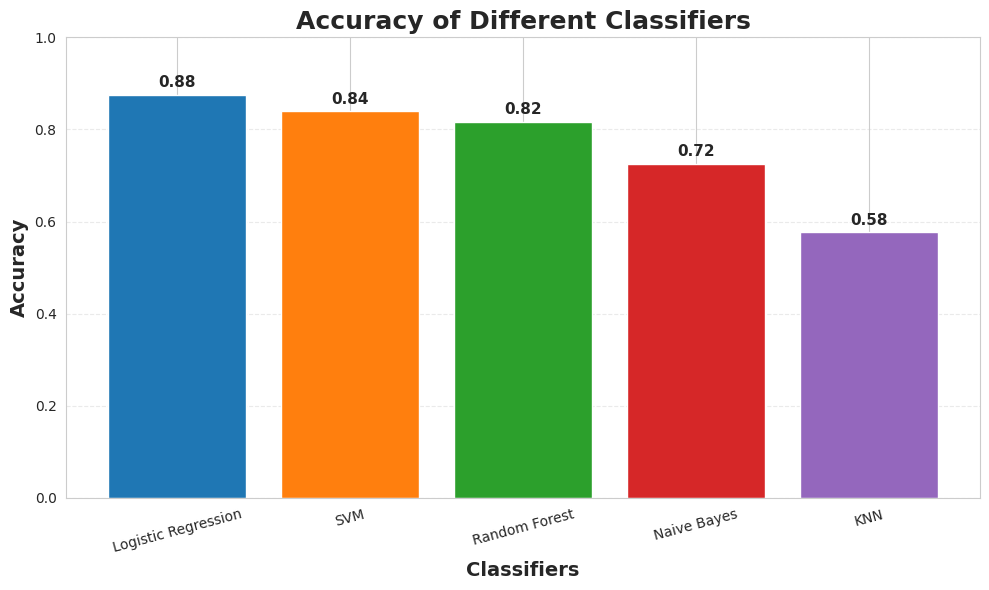

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVC # Added import
from sklearn.naive_bayes import MultinomialNB # Added import
from sklearn.neighbors import KNeighborsClassifier # Added import
from sklearn.metrics import accuracy_score # Added import

# Extract accuracy scores from the previously tuned models (Logistic Regression and Random Forest)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# --- Start of fix: Initialize and fit models for SVM, Naive Bayes, KNN ---
# These models were not subjected to GridSearch in the latest execution of the previous cell,
# so we initialize and fit them with default parameters to calculate their accuracies.

# SVM Model
svm_model = SVC(random_state=42) # Using a default SVC instance
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# Naive Bayes Model
nb_model = MultinomialNB() # Using a default MultinomialNB instance
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

# KNN Model
knn_model = KNeighborsClassifier() # Using a default KNeighborsClassifier instance
knn_model.fit(X_train_tfidf, y_train)
y_pred_knn = knn_model.predict(X_test_tfidf)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
# --- End of fix ---

# Decision Tree was not explicitly tuned or used for prediction in the previous cell
# Adding a placeholder or implementing it if necessary, for now assuming it's not a tuned model
# If a DecisionTreeClassifier was intended, it should be added in the previous cell's GridSearchCV section
# For this plot, I will use a placeholder or remove it if no DT model was created.
# Assuming we want to show the results of the models that were actually tuned and predicted.

# Create the DataFrame for plotting
hasil_model = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Random Forest', 'Naive Bayes', 'KNN'],
    'Test Accuracy': [accuracy_lr, accuracy_svm, accuracy_rf, accuracy_nb, accuracy_knn]
})

plt.figure(figsize=(10,6))

# Warna berbeda untuk setiap model
colors = [
    "#1f77b4",  # Logistic Regression - Biru
    "#ff7f0e",  # SVM - Oranye
    "#2ca02c",  # Random Forest - Hijau
    "#d62728",  # Naive Bayes - Merah
    "#9467bd",  # KNN - Ungu
    "#8c564b"   # Decision Tree - Cokelat (Placeholder, not used if DT not present)
]

# Ensure colors list matches the number of models in hasil_model
plot_colors = colors[:len(hasil_model)]

bars = plt.bar(
    hasil_model["Model"],
    hasil_model["Test Accuracy"],
    color=plot_colors
)

plt.title("Accuracy of Different Classifiers", fontsize=18, fontweight="bold")
plt.xlabel("Classifiers", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy", fontsize=14, fontweight="bold")

plt.ylim(0, 1)

# Menampilkan nilai di atas setiap batang
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Conclusion**

Based on the machine learning evaluation results, Logistic Regression achieved the highest performance among all tested algorithms, reaching an accuracy rate of 88% (0.88). This makes it the most suitable model for classifying sentiment in this dataset compared to alternatives like SVM (84%), Random Forest (82%), Naive Bayes (72%), and KNN (58%). The model's exceptional capability in handling high-dimensional sparse data—a common characteristic of text features processed via TF-IDF or Bag-of-Words—allows it to map relationships between words and sentiment categories with high precision.


Beyond its superior accuracy, Logistic Regression offers distinct operational advantages in practical machine learning workflows. Its linear nature provides clear interpretability through feature coefficients, making it easy to identify which specific words strongly drive positive or negative predictions. Furthermore, it requires low computational resources and delivers fast training and inference speeds, making it an efficient choice for deployment in real-time applications while remaining resistant to overfitting through standard regularization techniques.   